# Notebook 04 — Data Visualization
**Decodelabs Internship | Week 1 | Task 4**

This notebook is for informative visualisations of the Heart Disease dataset.


## Importing libraries and load data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set global plot style for consistent, clean figures
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})
sns.set_palette("colorblind")  # Colourblind-safe palette

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
CLEAN_FILE   = os.path.join(PROJECT_ROOT, "data", "processed", "heart_cleveland_clean.csv")
FIGURES_DIR  = os.path.join(PROJECT_ROOT, "reports", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

df = pd.read_csv(CLEAN_FILE)

# Convenience: a colour for each class
COLORS = {0: "#4878CF", 1: "#D65F5F"}
TARGET_LABELS = {0: "No Disease", 1: "Heart Disease"}

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Figures will be saved to: {FIGURES_DIR}")

Dataset: 297 rows × 14 columns
Figures will be saved to: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures


## Figure 1 — Target class distribution (bar chart)

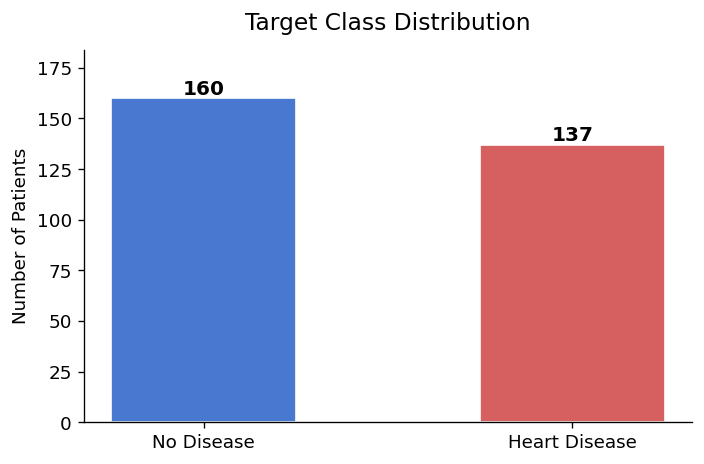

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\01_class_distribution.png


In [ ]:
# The first thing to show is how many patients fall into each class.

counts = df["target"].value_counts().sort_index()
labels = ["No Disease", "Heart Disease"]
colors = [COLORS[0], COLORS[1]]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(labels, counts.values, color=colors, width=0.5, edgecolor="white")

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(count), ha="center", fontsize=12, fontweight="bold")

ax.set_title("Target Class Distribution", fontsize=14, pad=12)
ax.set_ylabel("Number of Patients")
ax.set_ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "01_class_distribution.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Figure 2 — Age distribution by disease group

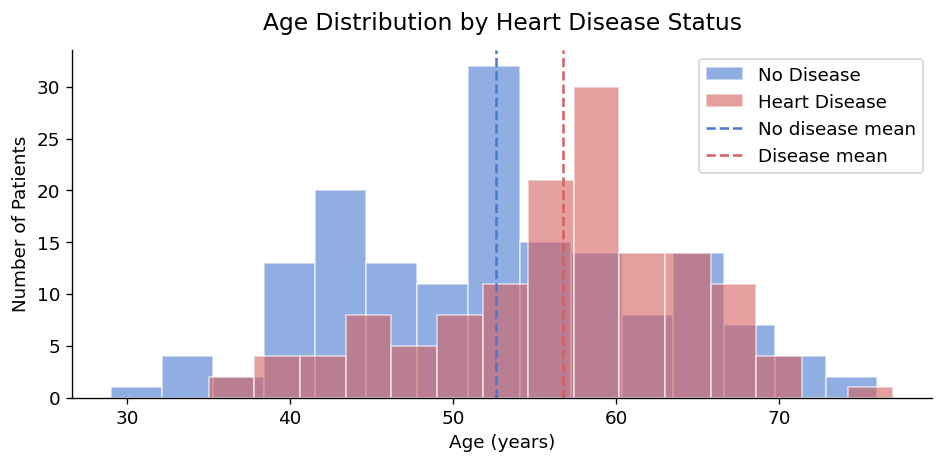

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\02_age_distribution_by_target.png


In [3]:
# I compared the age distribution for patients with and without heart disease.

fig, ax = plt.subplots(figsize=(8, 4))

for target_val, label in TARGET_LABELS.items():
    subset = df[df["target"] == target_val]["age"]
    ax.hist(subset, bins=15, alpha=0.6, label=label,
            color=COLORS[target_val], edgecolor="white")

ax.axvline(df[df.target==0]["age"].mean(), color=COLORS[0],
           linestyle="--", linewidth=1.5, label=f"No disease mean")
ax.axvline(df[df.target==1]["age"].mean(), color=COLORS[1],
           linestyle="--", linewidth=1.5, label=f"Disease mean")

ax.set_title("Age Distribution by Heart Disease Status", fontsize=14, pad=12)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Patients")
ax.legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "02_age_distribution_by_target.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Figure 3 — Boxplots: continuous features by disease group

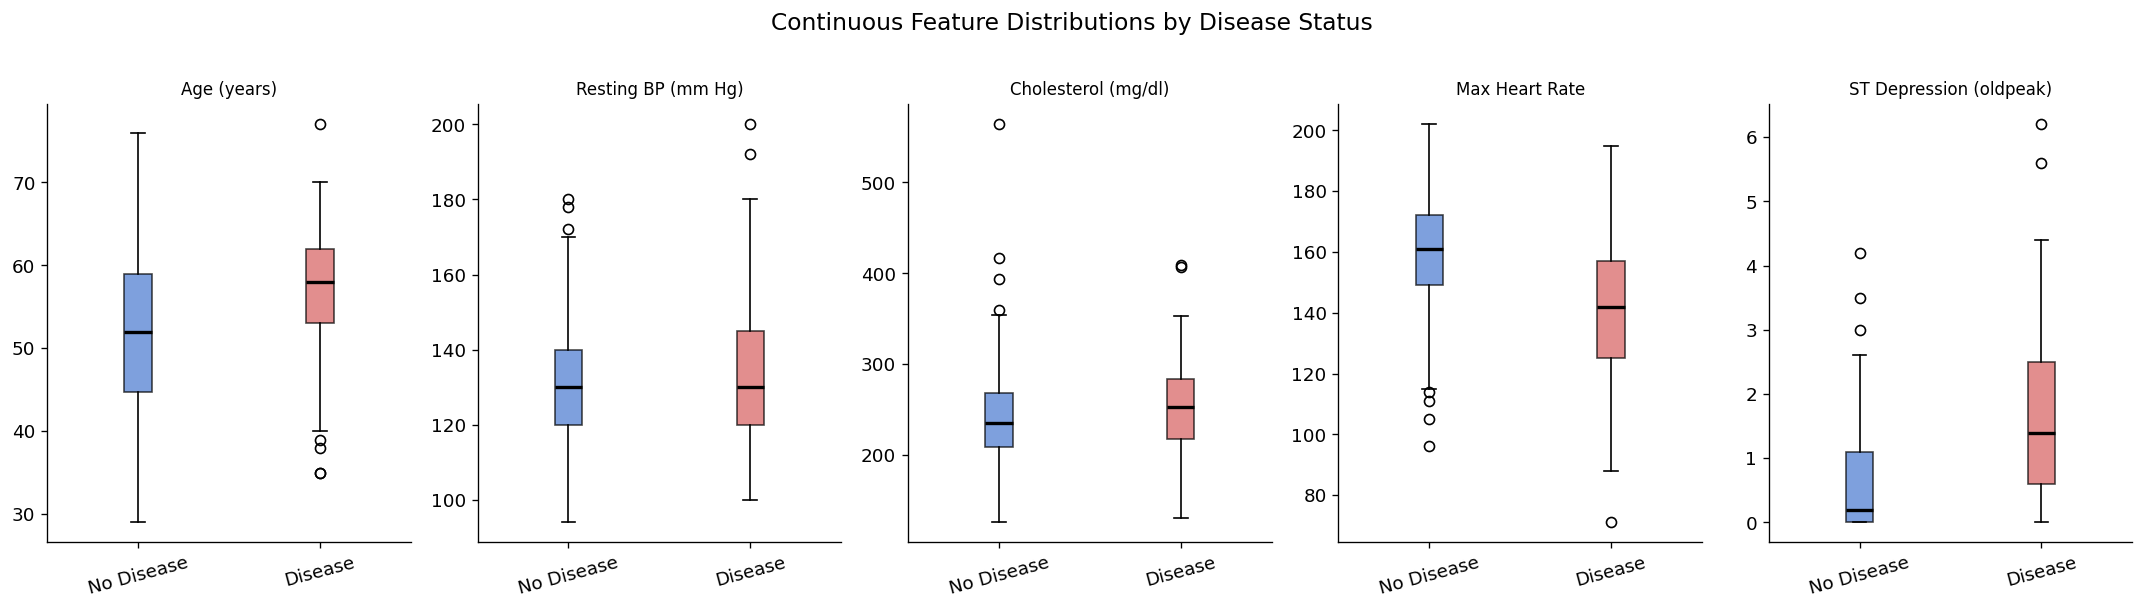

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\03_boxplots_by_target.png


In [4]:
# The boxplots shows Q1, median, Q3. Whiskers extend to 1.5*IQR.
# Points beyond the whiskers are potential outliers.

continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
feature_labels = {
    "age": "Age (years)",
    "trestbps": "Resting BP (mm Hg)",
    "chol": "Cholesterol (mg/dl)",
    "thalach": "Max Heart Rate",
    "oldpeak": "ST Depression (oldpeak)"
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, continuous_features):
    # Create a list of values for each group
    group_0 = df[df.target == 0][col].values
    group_1 = df[df.target == 1][col].values
    
    bp = ax.boxplot([group_0, group_1],
                    patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    
    bp["boxes"][0].set_facecolor(COLORS[0])
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor(COLORS[1])
    bp["boxes"][1].set_alpha(0.7)
    
    ax.set_xticklabels(["No Disease", "Disease"], rotation=15)
    ax.set_title(feature_labels[col], fontsize=10)

fig.suptitle("Continuous Feature Distributions by Disease Status", fontsize=14, y=1.01)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "03_boxplots_by_target.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Figure 4 — Correlation heatmap

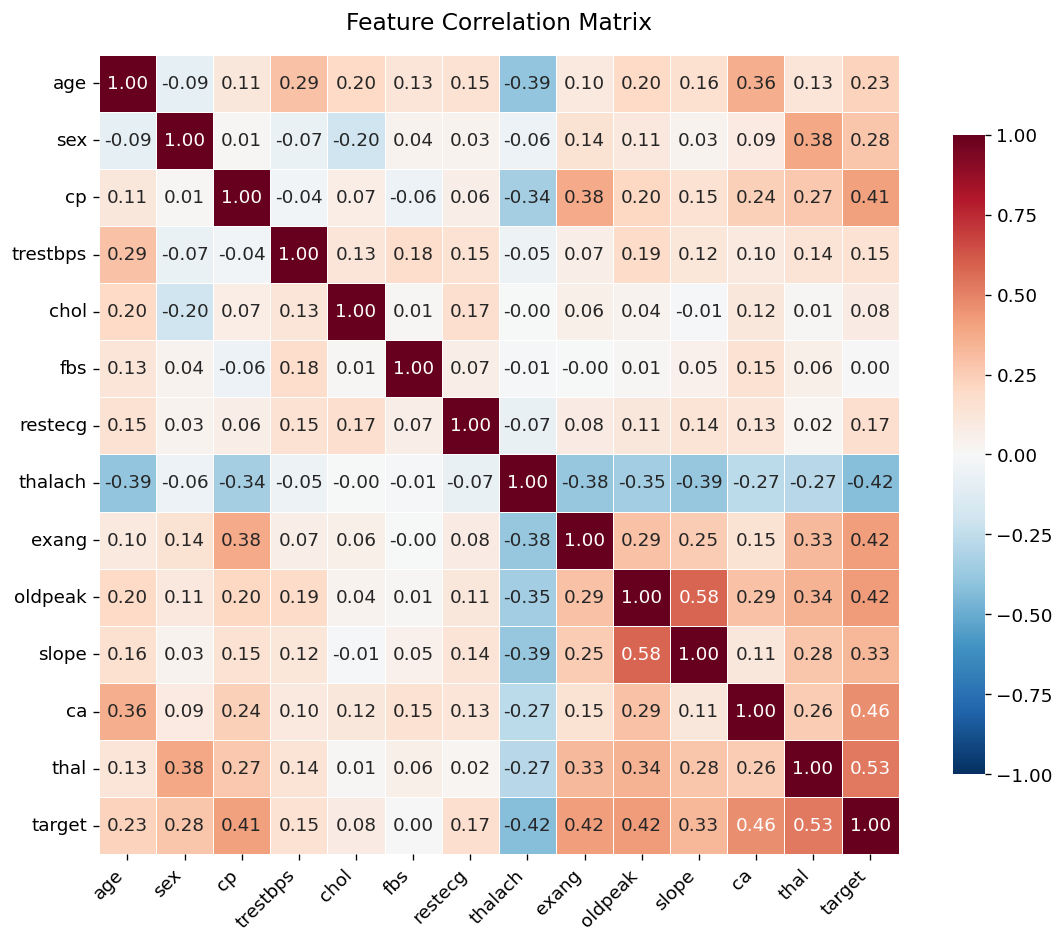

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\04_correlation_heatmap.png


In [5]:
# A heatmap of the correlation matrix shows all pairwise linear relationships.
# I use a diverging colour palette: red = positive, blue = negative, white = ~0.

corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,          # Show the correlation values in each cell
    fmt=".2f",           # 2 decimal places
    cmap="RdBu_r",       # Diverging: red=positive, blue=negative
    center=0,            # Centre the colour scale at 0
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "04_correlation_heatmap.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Figure 5 — Chest pain type vs disease (bar chart)

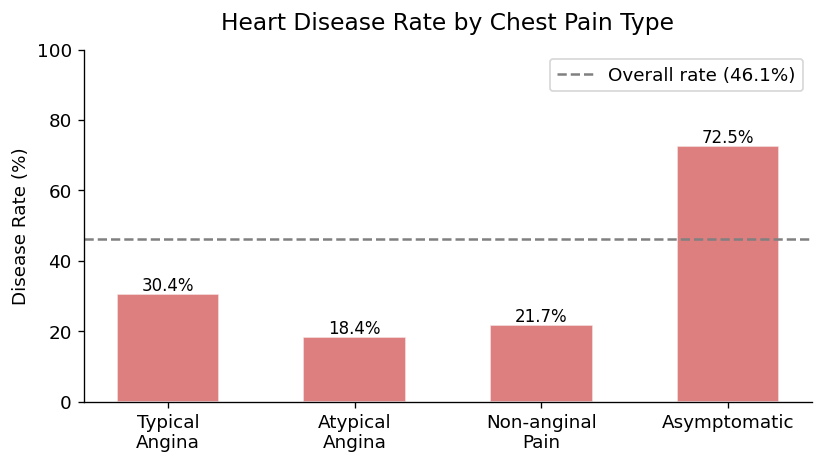

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\05_chest_pain_disease_rate.png


In [6]:
# Chest pain type (cp) is one of the most informative categorical features.
# I plotted the disease rate for each chest pain type.

cp_labels = {1: "Typical\nAngina", 2: "Atypical\nAngina",
             3: "Non-anginal\nPain", 4: "Asymptomatic"}

disease_rate = df.groupby("cp")["target"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    [cp_labels[k] for k in sorted(disease_rate.index)],
    disease_rate.sort_index().values,
    color="#D65F5F", alpha=0.8, edgecolor="white", width=0.55
)

for bar, rate in zip(bars, disease_rate.sort_index().values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{rate:.1f}%", ha="center", fontsize=10)

ax.axhline(df["target"].mean() * 100, color="gray",
           linestyle="--", label=f"Overall rate ({df['target'].mean()*100:.1f}%)")
ax.set_ylim(0, 100)
ax.set_ylabel("Disease Rate (%)")
ax.set_title("Heart Disease Rate by Chest Pain Type", fontsize=14, pad=12)
ax.legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "05_chest_pain_disease_rate.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Figure 6 — Max heart rate vs age, coloured by disease

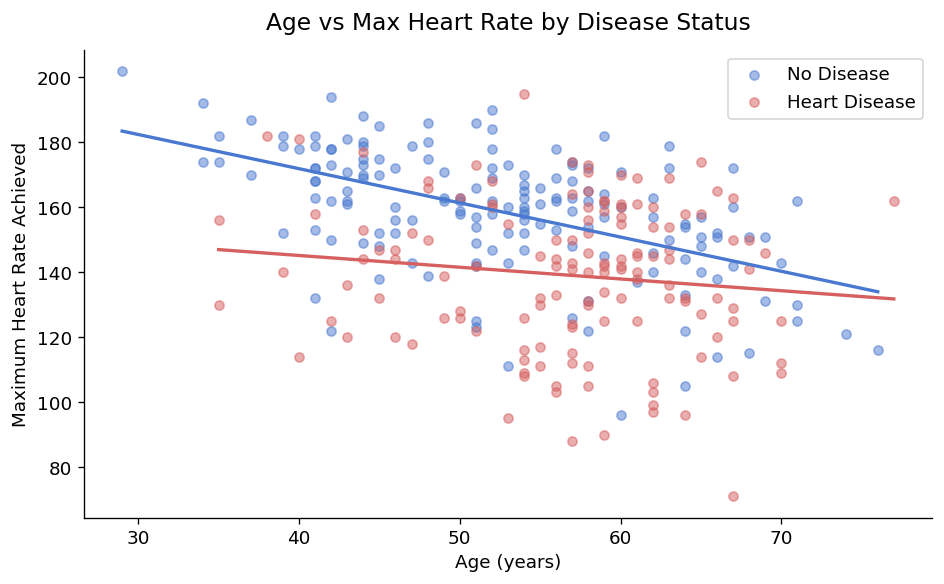

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\06_age_vs_thalach_scatter.png


In [7]:
# A scatter plot lets me see two continuous features at once.
# Colouring by disease status shows whether the groups cluster differently.
# I also plot a trend line for each group to show the average relationship.

fig, ax = plt.subplots(figsize=(8, 5))

for target_val, label in TARGET_LABELS.items():
    subset = df[df["target"] == target_val]
    ax.scatter(subset["age"], subset["thalach"],
               color=COLORS[target_val], alpha=0.5, label=label, s=30)
    
    # Trend line using numpy polyfit (linear regression line)
    z = np.polyfit(subset["age"], subset["thalach"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset["age"].min(), subset["age"].max(), 100)
    ax.plot(x_line, p(x_line), color=COLORS[target_val], linewidth=2)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Maximum Heart Rate Achieved")
ax.set_title("Age vs Max Heart Rate by Disease Status", fontsize=14, pad=12)
ax.legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "06_age_vs_thalach_scatter.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Figure 7 — Disease rate by sex

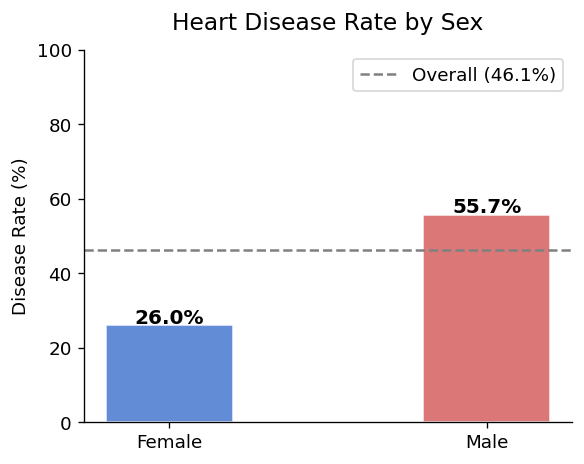

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\07_disease_rate_by_sex.png


In [8]:
# A simple grouped bar chart comparing disease rates between males and females.

sex_disease = df.groupby("sex")["target"].mean() * 100
labels = ["Female", "Male"]

fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(labels, sex_disease.values, color=[COLORS[0], COLORS[1]],
              width=0.4, alpha=0.85, edgecolor="white")

for bar, rate in zip(bars, sex_disease.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{rate:.1f}%", ha="center", fontsize=12, fontweight="bold")

ax.axhline(df["target"].mean() * 100, color="gray",
           linestyle="--", label=f"Overall ({df['target'].mean()*100:.1f}%)")
ax.set_ylim(0, 100)
ax.set_ylabel("Disease Rate (%)")
ax.set_title("Heart Disease Rate by Sex", fontsize=14, pad=12)
ax.legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "07_disease_rate_by_sex.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Figure 8 — Feature correlation with target (bar chart)

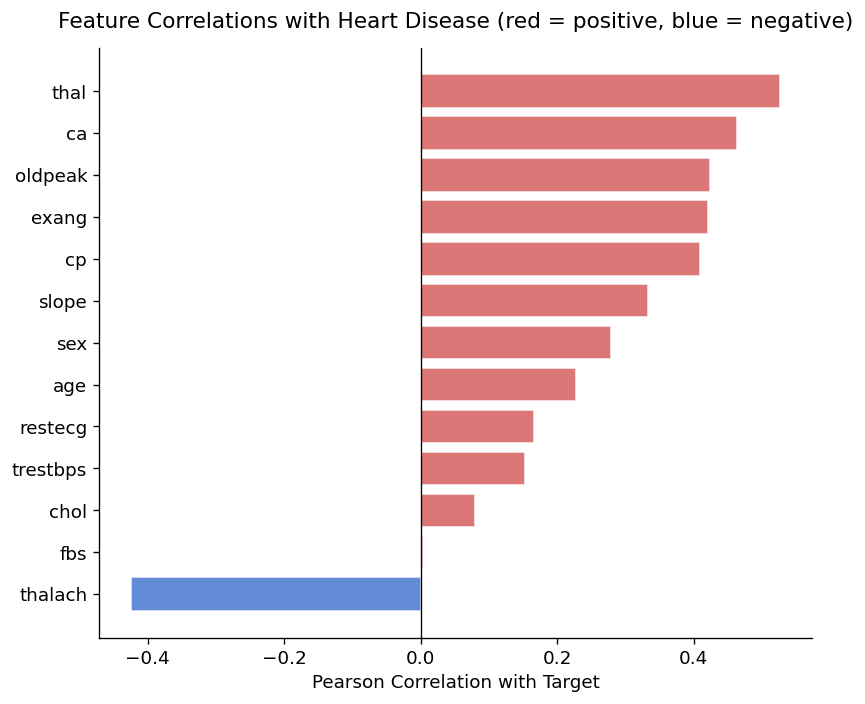

Figure saved: c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\heart_disease_analysis\reports\figures\08_feature_correlations_with_target.png


In [11]:
# This figure summarises which features are most correlated with the target.
# It gives a quick visual answer to the core research question.

corr_target = df.corr()["target"].drop("target").sort_values()

colors_bar = ["#D65F5F" if c > 0 else "#4878CF" for c in corr_target.values]

fig, ax = plt.subplots(figsize=(7, 6))

bars = ax.barh(corr_target.index, corr_target.values, color=colors_bar, alpha=0.85, edgecolor="white")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Target")
ax.set_title("Feature Correlations with Heart Disease (red = positive, blue = negative)", fontsize=13, pad=12)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "08_feature_correlations_with_target.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Summary — All figures saved

In [12]:
# I list all figures that were saved during this notebook.

figures = sorted([f for f in os.listdir(FIGURES_DIR) if f.endswith(".png")])
print(f"Total figures saved: {len(figures)}")
print()
for i, fig_name in enumerate(figures, 1):
    print(f"  {i:2d}. {fig_name}")

Total figures saved: 8

   1. 01_class_distribution.png
   2. 02_age_distribution_by_target.png
   3. 03_boxplots_by_target.png
   4. 04_correlation_heatmap.png
   5. 05_chest_pain_disease_rate.png
   6. 06_age_vs_thalach_scatter.png
   7. 07_disease_rate_by_sex.png
   8. 08_feature_correlations_with_target.png


## **Key visual findings**

- The dataset is reasonably balanced between the two classes.
- Disease patients tend to have **lower max heart rate** (thalach) — this is visible in both the boxplot and scatter plot.
- **Chest pain type 4 (asymptomatic)** has an unexpectedly high disease rate — this is a counter-intuitive but well-documented clinical finding.
- Males in this dataset have a notably higher disease rate than females.
- The correlation heatmap confirms that `cp`, `thalach`, and `exang` are the features most associated with the target.

**Next step:** Notebook 05 — Predictive Model
